# EDA — Muestra estratificada de artículos de prensa (2019–2026)

Análisis exploratorio de `data/raw/stratified_sample_2019_2026.csv` (~9,551 artículos de
**Diario Expreso**, **El Universo** y **Primicias**), seguido de **cuatro métodos de
transformación texto → embedding** (más una variante) y su visualización con **PCA** y
**t-SNE** sobre una submuestra estratificada.

Métodos de embedding:
1. **TF-IDF** (bolsa de palabras ponderada, scikit-learn)
2. **sentence-transformers** local (`paraphrase-multilingual-MiniLM-L12-v2`, 384 dims)
3. **BGE-M3** vía vLLM (servidor H200 de la universidad, 1024 dims — requiere VPN GlobalProtect)
4. **BETO** (`dccuchile/bert-base-spanish-wwm-cased`, 768 dims) con chunking + pooling,
   calculado fuera del notebook por `scripts/embed_beto.py`
   - 4b. **BETO whitened** — la misma matriz centrada y descorrelacionada a 128 dims

**Advertencia de comparabilidad:** los métodos 1–3 ven el texto **truncado a 2,000
caracteres**; BETO ve el **artículo completo** vía ventanas solapadas. Parte de cualquier
diferencia que se observe es cantidad de texto procesado, no calidad del modelo. El
notebook `hc_clustering.ipynb` cuantifica ese efecto con η² de longitud.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Raíz del repo en el path (para importar src.llm_clients, como en scripts/check_vllm.py)
sys.path.insert(0, str(Path.cwd().parent))

# Paleta categórica fija por periódico (orden alfabético estable)
PALETA = ["#2a78d6", "#008300", "#e87ba4"]  # azul, verde, magenta
COLOR_FLAG = {0: "#c3c2b7", 1: "#2a78d6"}   # gris neutro / azul

sns.set_theme(style="whitegrid", palette=PALETA)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.color": "#e1e0d9",
                     "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e"})
RANDOM_STATE = 42

## Carga y limpieza inicial

In [2]:
data = pd.read_csv("../data/raw/stratified_sample_2019_2026.csv")
data

,id_articulo,id_pressreader,titulo,texto,seccion,fecha,id_periodico,nombre_periodico,anio,incertidumbre,economic_uncertainty,political_uncertainty,icor_index,icor_v2_index,icor_v3_1_index
0,109760,NaN,Un Ejemplo De Superación Sobre Ruedas,"VELOCIDAD Y ADRENALINA. EL KARTING, UN DEPORTE...",Portada,2019-08-18,2,Diario Expreso,2019,0,0,0,0,0,0
1,109761,NaN,“El Gobierno Dejó Un Mensaje Con Espinosa: Pro...,Semana de juicios en la Asamblea. El legislado...,Portada,2019-08-18,2,Diario Expreso,2019,0,0,0,0,0,0
2,109762,NaN,Venta Informal De Comida Falsa,254.161 PRODUCTOS irregulares se han detectado...,Portada,2019-08-18,2,Diario Expreso,2019,0,0,0,0,0,0
3,109763,NaN,Virgin Galactic Explora El Negocio De Los Viaj...,"Algún día, no muy lejano, las vacaciones fuera...",Portada,2019-08-18,2,Diario Expreso,2019,0,0,0,0,0,0
4,109764,NaN,Policía Emite La Orden De Búsqueda A Correa,Se enviaron oficios a las unidades del país pa...,Portada,2019-08-18,2,Diario Expreso,2019,0,0,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,472045,NaN,Dinamarca Le Recuerda A Estados Unidos Que La ...,"La primera ministra de Dinamarca, Mette Freder...",Internacional,2026-07-08,4,Primicias,2026,0,0,0,0,0,0
9547,472107,NaN,¿Cuál Es El Estado De Salud De Aquiles Alvarez...,"El alcalde de Guayaquil, Aquiles Alvarez, perm...",Política,2026-07-08,4,Primicias,2026,0,0,0,0,0,0
9548,472156,NaN,Chofer De Bus En Estado Etílico Causa Accident...,Un nuevo accidente de tránsito protagonizado p...,Quito,2026-07-08,4,Primicias,2026,0,0,0,0,0,0
9549,472167,NaN,El Buque Escuela Guayas Causó Sensación En Nue...,NUEVA YORK. El Buque Escuela Guayas fue botado...,Sociedad,2026-07-09,4,Primicias,2026,0,0,0,0,0,0


In [3]:
data.drop(columns=["anio", "id_pressreader", "id_periodico", "icor_index", "icor_v2_index"], inplace=True)
data.rename({"incertidumbre": "u_index",
            "economic_uncertainty": "economic_u_index",
            "political_uncertainty": "political_u_index",},
            axis=1, inplace=True)

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   id_articulo        9551 non-null   int64
 1   titulo             9551 non-null   str  
 2   texto              9551 non-null   str  
 3   seccion            9549 non-null   str  
 4   fecha              9551 non-null   str  
 5   nombre_periodico   9551 non-null   str  
 6   u_index            9551 non-null   int64
 7   economic_u_index   9551 non-null   int64
 8   political_u_index  9551 non-null   int64
 9   icor_v3_1_index    9551 non-null   int64
dtypes: int64(5), str(5)
memory usage: 746.3 KB


In [5]:
data["fecha"] = pd.to_datetime(data["fecha"])
data["anio"] = data["fecha"].dt.year
data["fecha"]

0      2019-08-18
1      2019-08-18
2      2019-08-18
3      2019-08-18
4      2019-08-18
          ...    
9546   2026-07-08
9547   2026-07-08
9548   2026-07-08
9549   2026-07-09
9550   2026-07-09
Name: fecha, Length: 9551, dtype: datetime64[us]

In [6]:
data["seccion"].value_counts()

seccion
Portada                       968
Deportes                      711
Jugada                        649
Economía                      606
Opinión                       482
                             ... 
Festejos En Guayaquil           1
Búsqueda De Sobrevivientes      1
Crecimiento Económico           1
Sector Pesquero                 1
Hablemos                        1
Name: count, Length: 764, dtype: int64

## Calidad de datos

Nulos, duplicados y consistencia básica antes de cualquier análisis.

In [7]:
print("Nulos por columna:")
print(data.isna().sum())
print(f"\nDuplicados por id_articulo: {data['id_articulo'].duplicated().sum()}")
print(f"Duplicados por (titulo, texto): {data.duplicated(subset=['titulo', 'texto']).sum()}")
print(f"Textos vacíos: {(data['texto'].str.strip().str.len() == 0).sum()}")
print(f"Rango de fechas: {data['fecha'].min().date()} → {data['fecha'].max().date()}")

Nulos por columna:
id_articulo          0
titulo               0
texto                0
seccion              2
fecha                0
nombre_periodico     0
u_index              0
economic_u_index     0
political_u_index    0
icor_v3_1_index      0
anio                 0
dtype: int64

Duplicados por id_articulo: 0
Duplicados por (titulo, texto): 0
Textos vacíos: 0
Rango de fechas: 2019-03-31 → 2026-07-09


## Normalización de texto

Normalización **ligera** (minúsculas + colapso de espacios): suficiente para TF-IDF y
neutra para los modelos neuronales, que prefieren texto natural sin stemming ni
eliminación agresiva.

In [8]:
import re


def norm_text(text: str) -> str:
    """Normaliza un texto: minúsculas y colapso de espacios en blanco."""
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()


data["texto_norm"] = data["texto"].map(norm_text)
data["n_caracteres"] = data["texto_norm"].str.len()
data["n_palabras"] = data["texto_norm"].str.split().str.len()
data[["texto_norm", "n_caracteres", "n_palabras"]].head(3)

,texto_norm,n_caracteres,n_palabras
0,"velocidad y adrenalina. el karting, un deporte...",2804,461
1,semana de juicios en la asamblea. el legislado...,7410,1236
2,254.161 productos irregulares se han detectado...,5561,889


## Longitud de los textos

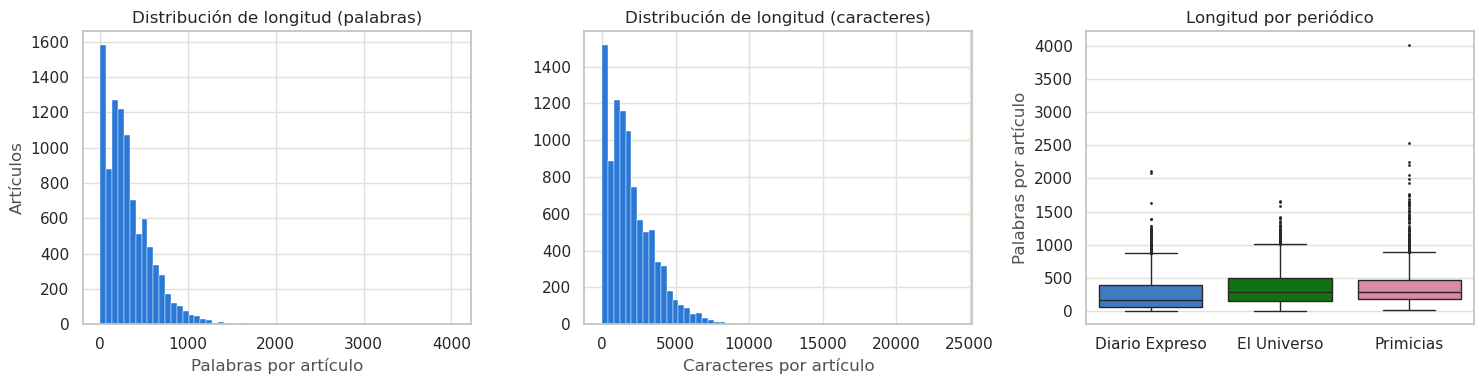

,n_palabras,n_caracteres
count,9551.0,9551.0
mean,320.0,1972.0
std,264.0,1621.0
min,1.0,1.0
25%,131.0,796.0
50%,260.0,1600.0
75%,459.0,2824.0
max,4019.0,23987.0


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(data["n_palabras"], bins=60, color="#2a78d6", edgecolor="white", linewidth=0.3)
axes[0].set_xlabel("Palabras por artículo")
axes[0].set_ylabel("Artículos")
axes[0].set_title("Distribución de longitud (palabras)")

axes[1].hist(data["n_caracteres"], bins=60, color="#2a78d6", edgecolor="white", linewidth=0.3)
axes[1].set_xlabel("Caracteres por artículo")
axes[1].set_title("Distribución de longitud (caracteres)")

orden_per = sorted(data["nombre_periodico"].unique())
sns.boxplot(data=data, x="nombre_periodico", y="n_palabras", order=orden_per,
            hue="nombre_periodico", hue_order=orden_per, palette=PALETA,
            legend=False, ax=axes[2], fliersize=1, linewidth=1)
axes[2].set_xlabel("")
axes[2].set_ylabel("Palabras por artículo")
axes[2].set_title("Longitud por periódico")

plt.tight_layout()
plt.show()

data[["n_palabras", "n_caracteres"]].describe().round(0)

## Cobertura muestral: año × periódico

Verificación del diseño estratificado (cuotas por estrato año × periódico).

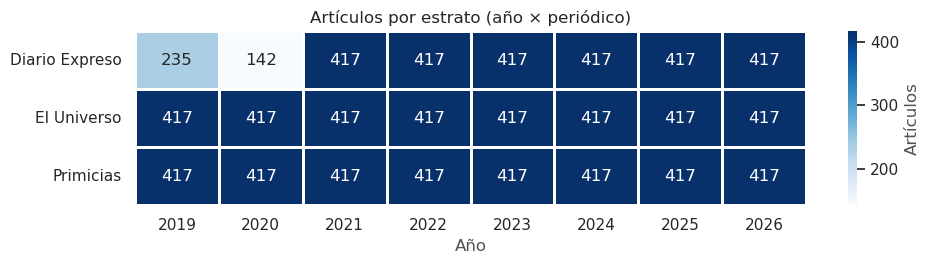

In [10]:
cobertura = data.pivot_table(index="nombre_periodico", columns="anio",
                             values="id_articulo", aggfunc="count", fill_value=0)

fig, ax = plt.subplots(figsize=(10, 2.8))
sns.heatmap(cobertura, annot=True, fmt="d", cmap="Blues", linewidths=2,
            linecolor="white", cbar_kws={"label": "Artículos"}, ax=ax)
ax.set_xlabel("Año")
ax.set_ylabel("")
ax.set_title("Artículos por estrato (año × periódico)")
plt.tight_layout()
plt.show()

## Secciones

Hay cientos de secciones distintas (etiquetado heterogéneo entre periódicos); se
muestran las 10 más frecuentes por periódico.

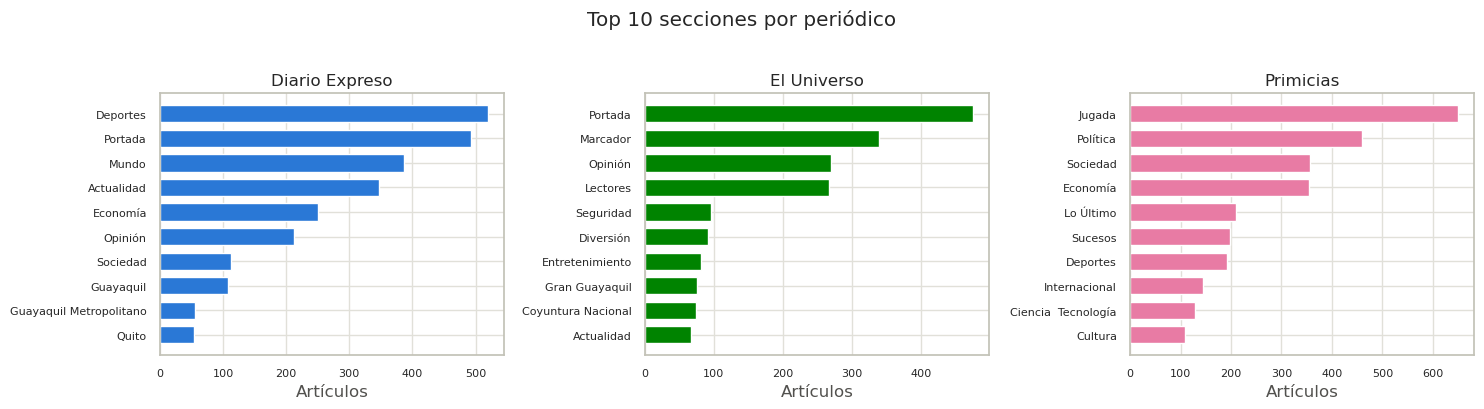

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=False)
for ax, periodico, color in zip(axes, orden_per, PALETA):
    top = (data.loc[data["nombre_periodico"] == periodico, "seccion"]
           .value_counts().head(10).sort_values())
    ax.barh(top.index, top.values, color=color, height=0.7)
    ax.set_title(periodico)
    ax.set_xlabel("Artículos")
    ax.tick_params(labelsize=8)
plt.suptitle("Top 10 secciones por periódico", y=1.02)
plt.tight_layout()
plt.show()

## Serie temporal: artículos por mes

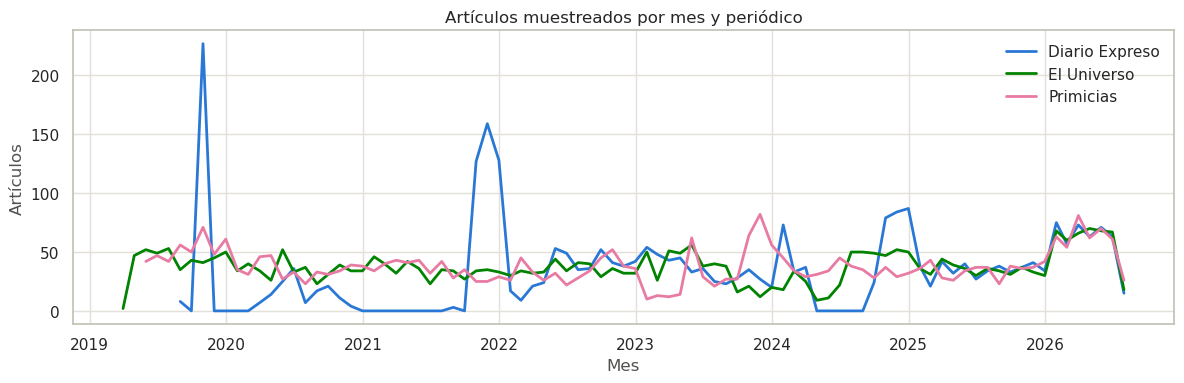

In [12]:
mensual = (data.set_index("fecha").groupby("nombre_periodico")
           .resample("ME")["id_articulo"].count().rename("articulos").reset_index())

fig, ax = plt.subplots(figsize=(12, 4))
for periodico, color in zip(orden_per, PALETA):
    serie = mensual[mensual["nombre_periodico"] == periodico]
    ax.plot(serie["fecha"], serie["articulos"], color=color, linewidth=2, label=periodico)
ax.set_xlabel("Mes")
ax.set_ylabel("Artículos")
ax.set_title("Artículos muestreados por mes y periódico")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## Flags de incertidumbre y corrupción

- `u_index`, `economic_u_index`, `political_u_index`: flags de incertidumbre ya
  almacenadas en la BD de origen.
- `icor_v3_1_index`: flag de detección de corrupción (versión 3.1, con exclusión).

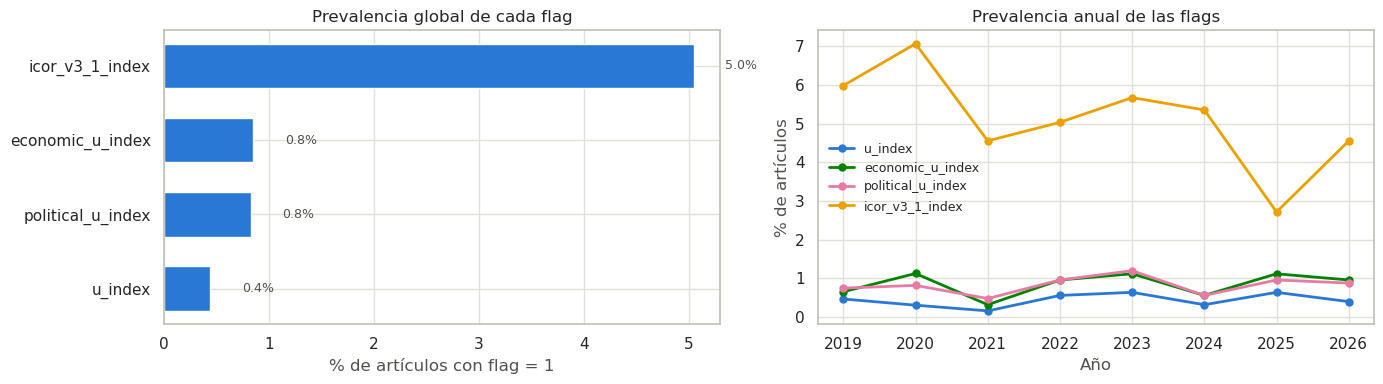

In [13]:
FLAGS = ["u_index", "economic_u_index", "political_u_index", "icor_v3_1_index"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

prevalencia = data[FLAGS].mean().sort_values() * 100
axes[0].barh(prevalencia.index, prevalencia.values, color="#2a78d6", height=0.6)
for i, v in enumerate(prevalencia.values):
    axes[0].text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9, color="#52514e")
axes[0].set_xlabel("% de artículos con flag = 1")
axes[0].set_title("Prevalencia global de cada flag")

anual = data.groupby("anio")[FLAGS].mean() * 100
colores_flags = ["#2a78d6", "#008300", "#e87ba4", "#eda100"]
for flag, color in zip(FLAGS, colores_flags):
    axes[1].plot(anual.index, anual[flag], color=color, linewidth=2, marker="o",
                 markersize=5, label=flag)
axes[1].set_xlabel("Año")
axes[1].set_ylabel("% de artículos")
axes[1].set_title("Prevalencia anual de las flags")
axes[1].legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

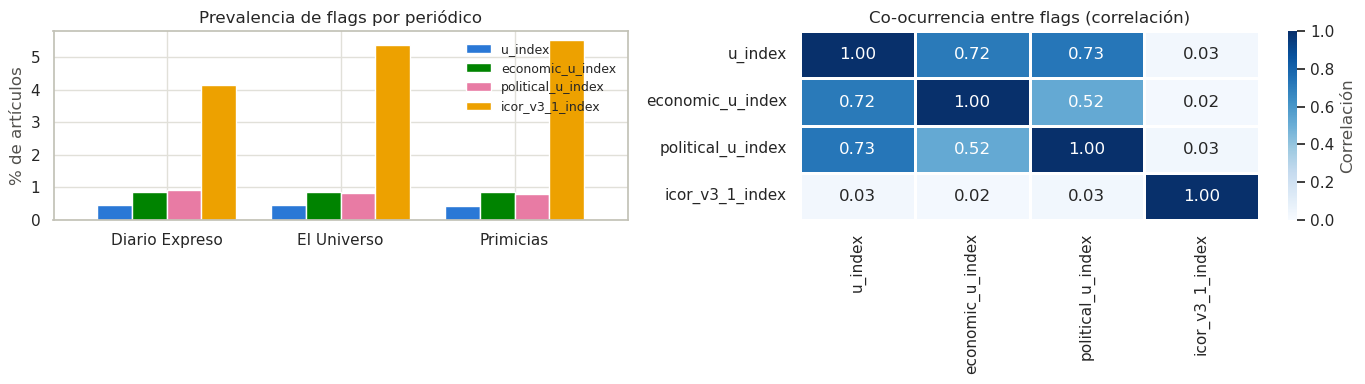

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

por_periodico = data.groupby("nombre_periodico")[FLAGS].mean().loc[orden_per] * 100
por_periodico.plot(kind="bar", ax=axes[0], color=colores_flags, width=0.8, edgecolor="white")
axes[0].set_xlabel("")
axes[0].set_ylabel("% de artículos")
axes[0].set_title("Prevalencia de flags por periódico")
axes[0].legend(frameon=False, fontsize=9)
axes[0].tick_params(axis="x", rotation=0)

sns.heatmap(data[FLAGS].corr(), annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            linewidths=2, linecolor="white", ax=axes[1], cbar_kws={"label": "Correlación"})
axes[1].set_title("Co-ocurrencia entre flags (correlación)")

plt.tight_layout()
plt.show()

---
# Embeddings

## Submuestra estratificada

Para mantener acotado el costo (t-SNE y las llamadas al servidor vLLM), los embeddings se
calculan sobre una **submuestra estratificada de ~1,500 artículos** (cuota fija por estrato
año × periódico, `random_state=42`). Como entrada se usa `titulo + texto` truncado a 2,000
caracteres (la media de longitud del corpus), que además respeta el límite de contexto de
los métodos 1–3.

**Excepción: BETO.** El método 4 no usa `textos_emb` sino el artículo completo sin truncar
— su razón de ser en este proyecto es cubrir todo el texto vía chunking (ver
`src/embeddings/beto.py`). Los vectores los produce `scripts/embed_beto.py`, que replica
esta misma submuestra y verifica los `id_articulo` contra `muestra_ids.npy`, así que las
filas siguen alineadas entre los cuatro métodos.


In [15]:
from math import ceil

N_MUESTRA = 1500
estratos = data.groupby(["nombre_periodico", "anio"])
cuota = ceil(N_MUESTRA / estratos.ngroups)

muestra = pd.concat(
    [g.sample(min(len(g), cuota), random_state=RANDOM_STATE) for _, g in estratos]
).sort_values(["anio", "nombre_periodico", "id_articulo"]).reset_index(drop=True)

textos_emb = (muestra["titulo"].fillna("").map(norm_text) + ". "
              + muestra["texto_norm"]).str.slice(0, 2000).tolist()

print(f"Submuestra: {len(muestra)} artículos ({estratos.ngroups} estratos, cuota {cuota})")
muestra["nombre_periodico"].value_counts()

Submuestra: 1512 artículos (24 estratos, cuota 63)


nombre_periodico
Diario Expreso    504
El Universo       504
Primicias         504
Name: count, dtype: int64

Los tres métodos cachean su resultado en `data/embeddings/` (ignorado por git) junto con
los `id_articulo` de la submuestra: si los ids coinciden, se reutiliza el caché en vez de
recalcular.

In [16]:
EMB_DIR = Path("../data/embeddings")
EMB_DIR.mkdir(parents=True, exist_ok=True)
ids_muestra = muestra["id_articulo"].to_numpy()
np.save(EMB_DIR / "muestra_ids.npy", ids_muestra)


def cargar_cache(nombre: str) -> np.ndarray | None:
    """Devuelve el embedding cacheado si corresponde a la submuestra actual."""
    ruta_emb, ruta_ids = EMB_DIR / f"{nombre}.npy", EMB_DIR / f"{nombre}_ids.npy"
    if ruta_emb.exists() and ruta_ids.exists() and np.array_equal(np.load(ruta_ids), ids_muestra):
        print(f"Caché válido: {ruta_emb}")
        return np.load(ruta_emb)
    return None


def guardar_cache(nombre: str, emb: np.ndarray) -> None:
    np.save(EMB_DIR / f"{nombre}.npy", emb)
    np.save(EMB_DIR / f"{nombre}_ids.npy", ids_muestra)

## Método 1: TF-IDF

Representación clásica de bolsa de palabras ponderada por frecuencia inversa de documento.
No captura semántica (dos sinónimos son dimensiones distintas), pero es un *baseline*
barato e interpretable. Se filtran términos muy raros (`min_df=3`) y muy frecuentes
(`max_df=0.6`), lo que elimina de paso la mayoría de stopwords del español.

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizador = TfidfVectorizer(max_features=50_000, min_df=3, max_df=0.6,
                               sublinear_tf=True)
emb_tfidf = vectorizador.fit_transform(textos_emb)
print(f"Matriz TF-IDF: {emb_tfidf.shape} (sparse, {emb_tfidf.nnz:,} valores no nulos)")

Matriz TF-IDF: (1512, 9931) (sparse, 149,898 valores no nulos)


## Método 2: sentence-transformers (local)

`paraphrase-multilingual-MiniLM-L12-v2`: modelo neuronal multilingüe que produce un vector
denso de **384 dimensiones** por documento. Captura similitud semántica, a costa de un
límite de secuencia corto (**128 tokens** ≈ los primeros ~100 palabras; el resto se
trunca). Corre localmente en CPU.

In [18]:
emb_st = cargar_cache("minilm_multilingual")
if emb_st is None:
    from sentence_transformers import SentenceTransformer

    modelo_st = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
    emb_st = modelo_st.encode(textos_emb, batch_size=64, show_progress_bar=True,
                              normalize_embeddings=True)
    guardar_cache("minilm_multilingual", emb_st)
print(f"Embeddings sentence-transformers: {emb_st.shape}")

Caché válido: ../data/embeddings/minilm_multilingual.npy
Embeddings sentence-transformers: (1512, 384)


## Método 3: BGE-M3 vía vLLM (servidor H200)

`BAAI/bge-m3` servido por la universidad (API compatible con OpenAI, cliente de
`src/llm_clients`). Vector denso de **1024 dimensiones**, contexto de hasta 8,192 tokens
(nuestros 2,000 caracteres entran completos). **Requiere VPN GlobalProtect activa.**

In [19]:
from tqdm.auto import tqdm

emb_bge = cargar_cache("bge_m3")
if emb_bge is None:
    from src.llm_clients import get_embedding_client, load_config

    config = load_config()
    cliente = get_embedding_client(config)
    LOTE = 32
    vectores = []
    for i in tqdm(range(0, len(textos_emb), LOTE), desc="BGE-M3"):
        respuesta = cliente.embeddings.create(model=config.embedding_model,
                                              input=textos_emb[i:i + LOTE])
        vectores.extend(d.embedding for d in respuesta.data)
    emb_bge = np.array(vectores, dtype=np.float32)
    guardar_cache("bge_m3", emb_bge)
print(f"Embeddings BGE-M3: {emb_bge.shape}")

Caché válido: ../data/embeddings/bge_m3.npy
Embeddings BGE-M3: (1512, 1024)


## Método 4: BETO (chunking + pooling)

`dccuchile/bert-base-spanish-wwm-cased`: BERT monolingüe de español, vector denso de
**768 dimensiones**. Su ventana es de solo **512 tokens**, insuficiente para un artículo
completo, así que el texto se parte en ventanas solapadas, cada chunk se resume con mean
pooling enmascarado y los vectores de chunk se promedian (ver `src/embeddings/beto.py`).

A diferencia de los tres métodos anteriores, **no se calcula en este notebook**: correrlo
en CPU toma ~10 minutos, así que vive en `scripts/embed_beto.py` y aquí solo se carga del
caché. Si la celda falla, ejecuta primero:

```bash
micromamba activate ai_env && python scripts/embed_beto.py
```

Nota: BETO **no tiene fine-tuning contrastivo de similitud** (a diferencia de MiniLM y
BGE-M3, entrenados con objetivos de oración). Es un modelo de propósito general, y eso se
nota en la geometría de su espacio — ver la variante whitened abajo.


In [20]:
emb_beto = cargar_cache("beto")
if emb_beto is None:
    raise FileNotFoundError(
        "No hay caché de BETO para esta submuestra. Ejecuta primero:\n"
        "    micromamba activate ai_env && python scripts/embed_beto.py"
    )
print(f"Embeddings BETO: {emb_beto.shape}")


Caché válido: ../data/embeddings/beto.npy
Embeddings BETO: (1512, 768)


### Método 4b: BETO whitened

El espacio de BETO es **anisotrópico**: los vectores se concentran en un cono estrecho y
el coseno entre dos artículos cualesquiera ronda 0.94, cuando economía y deportes
deberían ser casi ortogonales. La causa es una **dirección común** heredada del
preentrenamiento que domina el producto punto y entierra la señal temática.

Esto importa especialmente **para la visualización de este notebook**: si una dirección
concentra casi toda la varianza, la primera componente del PCA la captura a ella y no al
tema, y la proyección 2D resultante dice poco. El *whitening* (Su et al., 2021) centra los
vectores y aplica `W = Σ^(-1/2)`, dejando la covarianza en la identidad — la nube pasa de
cigarro alargado a esfera.

`Σ` se trunca a **128 componentes**: con 1,512 documentos y 768 dimensiones hay menos
muestras que parámetros de covarianza, así que estimarla completa es ruidoso.


In [21]:
N_COMP = 128


def whitening(emb: np.ndarray, n_comp: int = N_COMP) -> np.ndarray:
    """Centra y descorrelaciona `emb`, reteniendo las `n_comp` direcciones de mayor varianza."""
    mu = emb.mean(axis=0)
    centrado = emb - mu
    # SVD de la covarianza: U son las direcciones principales, s sus varianzas.
    U, s, _ = np.linalg.svd(np.cov(centrado, rowvar=False))
    W = U[:, :n_comp] / np.sqrt(s[:n_comp])  # Sigma^(-1/2) truncada
    return centrado @ W


emb_beto_w = whitening(emb_beto)
print(f"Embeddings BETO whitened: {emb_beto_w.shape}")

# Efecto sobre la anisotropía: coseno medio entre pares de documentos distintos.
from sklearn.preprocessing import normalize  # noqa: E402

for etiqueta, X in [("BETO", emb_beto), ("BETO whitened", emb_beto_w)]:
    Xn = normalize(X)
    cos = (Xn @ Xn.T)[np.triu_indices(len(Xn), k=1)]
    print(f"{etiqueta}: coseno medio entre documentos = {cos.mean():.3f} "
          f"(desv. {cos.std():.3f})")


Embeddings BETO whitened: (1512, 128)
BETO: coseno medio entre documentos = 0.937 (desv. 0.029)
BETO whitened: coseno medio entre documentos = -0.000 (desv. 0.087)


---
# Visualización: PCA y t-SNE

Para cada método se proyecta a 2D de dos formas:

- **PCA** (lineal, preserva estructura global). Para TF-IDF se usa `TruncatedSVD`, el
  equivalente para matrices sparse (≈ LSA).
- **t-SNE** (no lineal, preserva vecindades locales), aplicado sobre una reducción previa
  a 50 componentes — práctica estándar para estabilizar y acelerar t-SNE.

In [22]:
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE


def proyectar(emb, es_sparse: bool):
    """Devuelve (proyección PCA 2D, proyección t-SNE 2D, varianza explicada 2D)."""
    Reductor = TruncatedSVD if es_sparse else PCA
    red2 = Reductor(n_components=2, random_state=RANDOM_STATE)
    xy_pca = red2.fit_transform(emb)
    var2 = red2.explained_variance_ratio_.sum()

    n50 = min(50, (emb.shape[1] - 1) if es_sparse else emb.shape[1])
    x50 = Reductor(n_components=n50, random_state=RANDOM_STATE).fit_transform(emb)
    xy_tsne = TSNE(n_components=2, init="pca", perplexity=30, max_iter=1000,
                   random_state=RANDOM_STATE).fit_transform(x50)
    return xy_pca, xy_tsne, var2


metodos = {
    "TF-IDF": (emb_tfidf, True),
    "MiniLM multilingüe": (emb_st, False),
    "BGE-M3": (emb_bge, False),
    "BETO": (emb_beto, False),
    "BETO whitened": (emb_beto_w, False),
}
proyecciones = {nombre: proyectar(emb, sp) for nombre, (emb, sp) in metodos.items()}
print(f"Proyecciones calculadas para {len(proyecciones)} métodos.")


Proyecciones calculadas para 5 métodos.


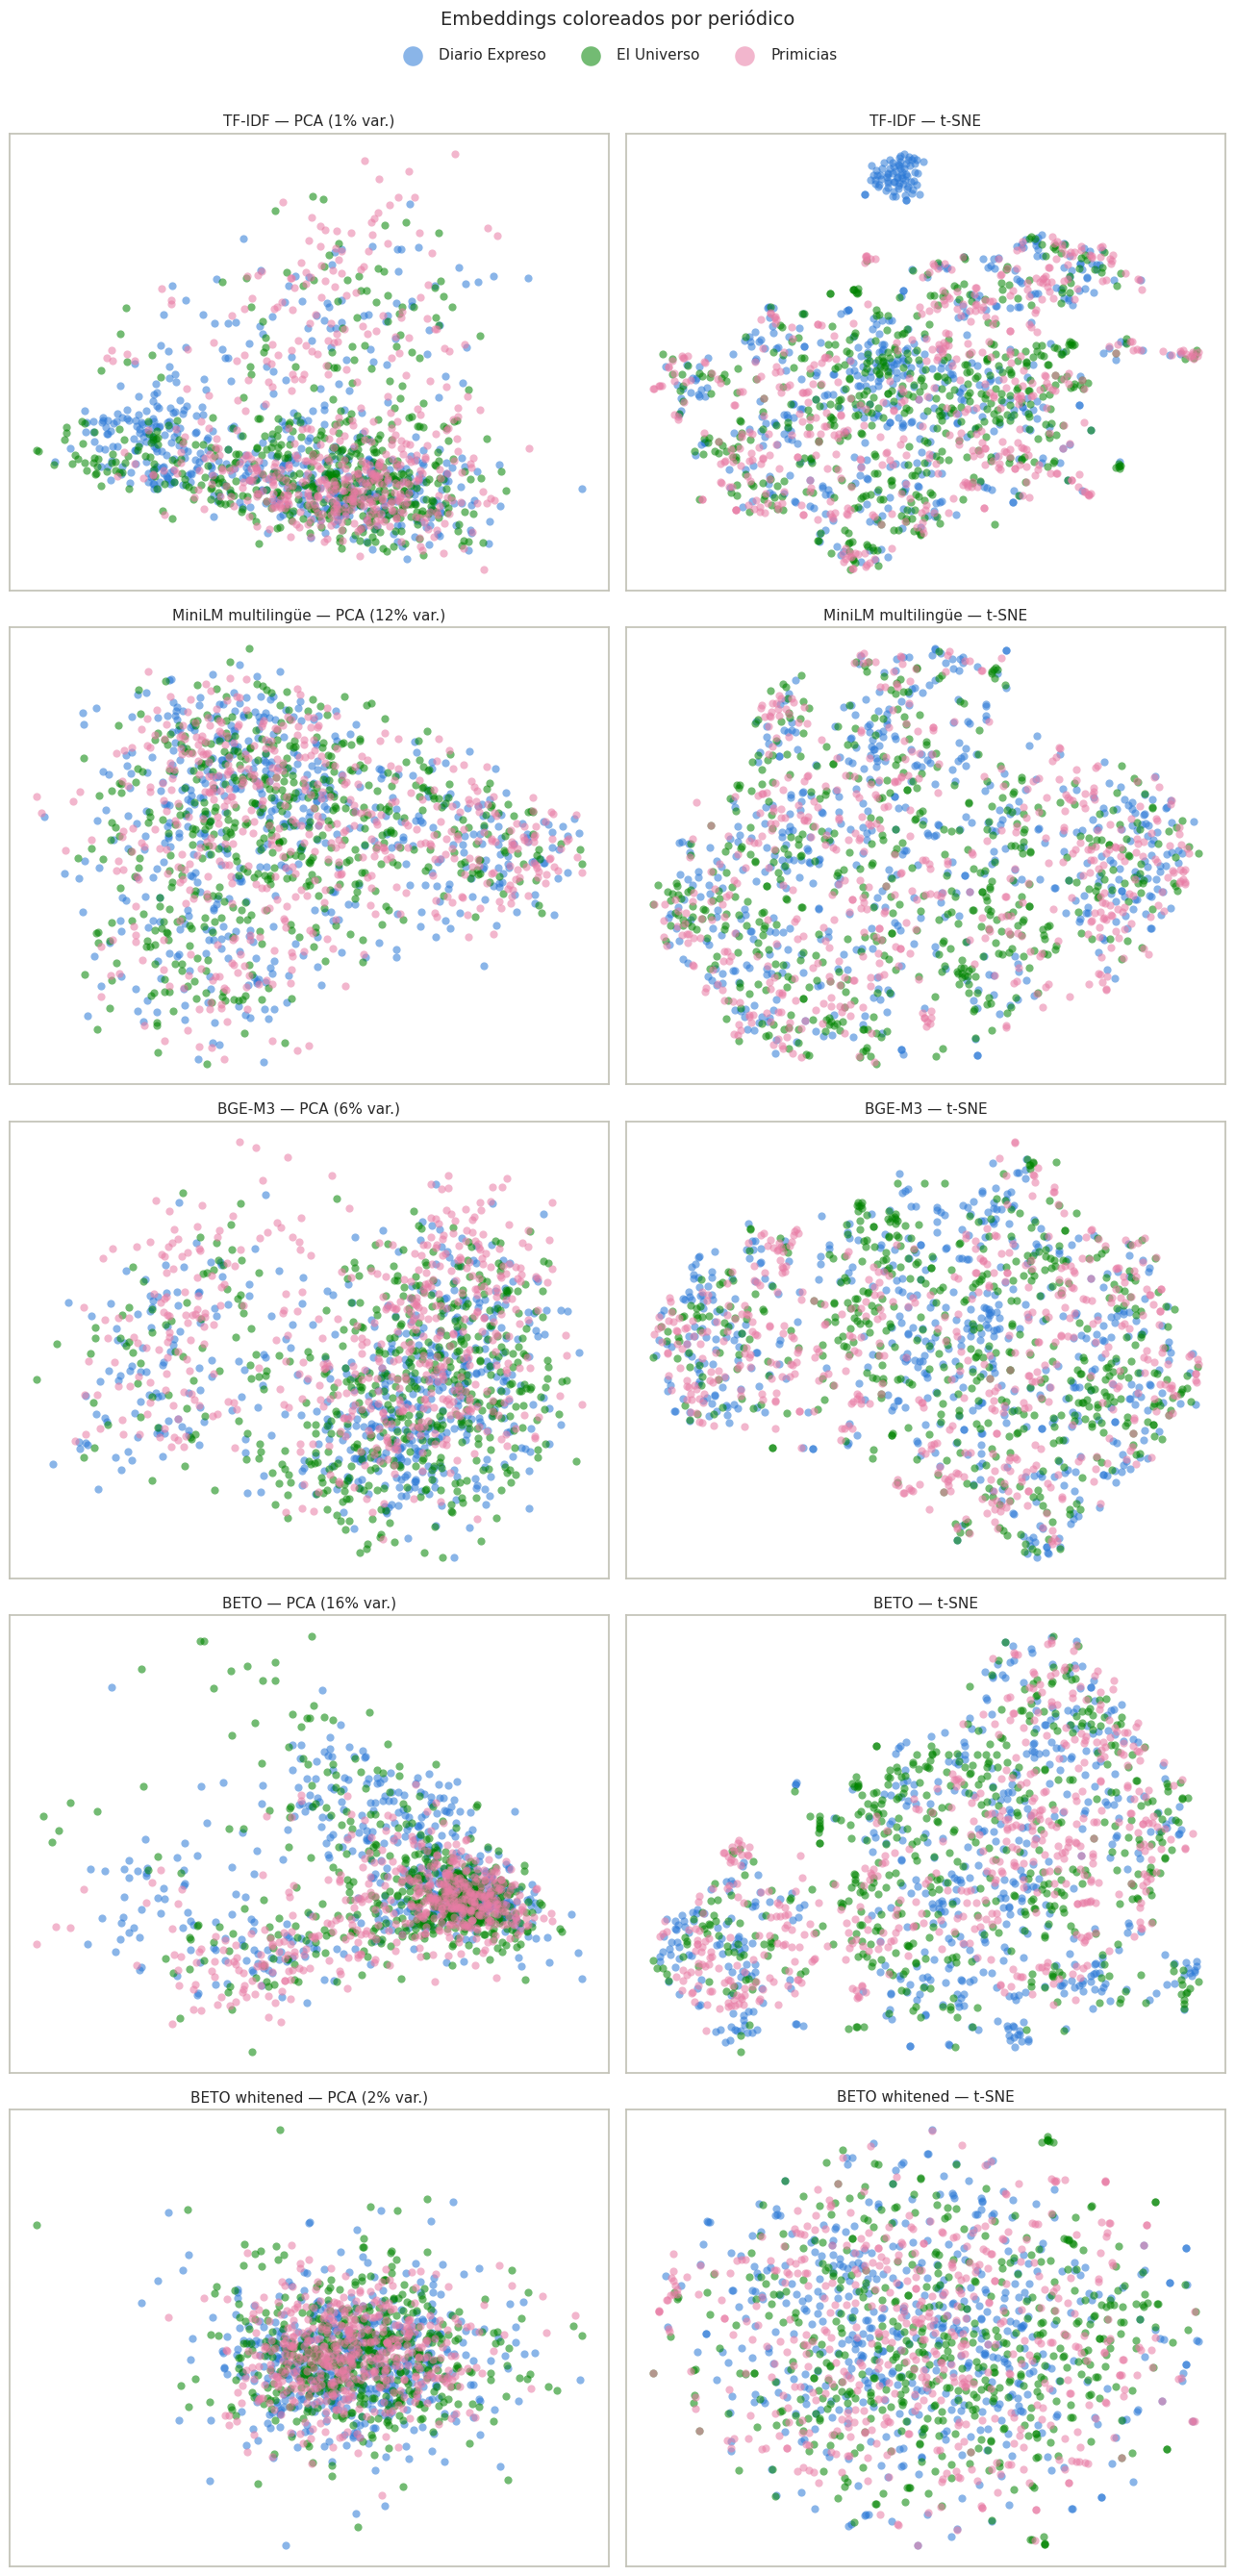

In [23]:
def plot_proyecciones(color_por: str, titulo: str, colores: dict, etiquetas: dict):
    # Una fila por método: el número de filas se deriva de `proyecciones`, nunca fijo,
    # para que añadir un método no lo deje fuera del gráfico en silencio.
    nfilas = len(proyecciones)
    fig, axes = plt.subplots(nfilas, 2, figsize=(13, 5.3 * nfilas), squeeze=False)
    for fila, (nombre, (xy_pca, xy_tsne, var2)) in enumerate(proyecciones.items()):
        for col, (xy, tipo) in enumerate([(xy_pca, f"PCA ({var2:.0%} var.)"), (xy_tsne, "t-SNE")]):
            ax = axes[fila, col]
            for valor, color in colores.items():
                mascara = (muestra[color_por] == valor).to_numpy()
                ax.scatter(xy[mascara, 0], xy[mascara, 1], s=35, alpha=0.55, color=color,
                           label=etiquetas[valor], linewidths=0)
            ax.set_title(f"{nombre} — {tipo}", fontsize=11)
            ax.set_xticks([])
            ax.set_yticks([])
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=len(colores), frameon=False,
               bbox_to_anchor=(0.5, 1.0), markerscale=2.5)
    fig.suptitle(titulo, y=1.01, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    plt.show()


plot_proyecciones("nombre_periodico", "Embeddings coloreados por periódico",
                  dict(zip(orden_per, PALETA)), {p: p for p in orden_per})


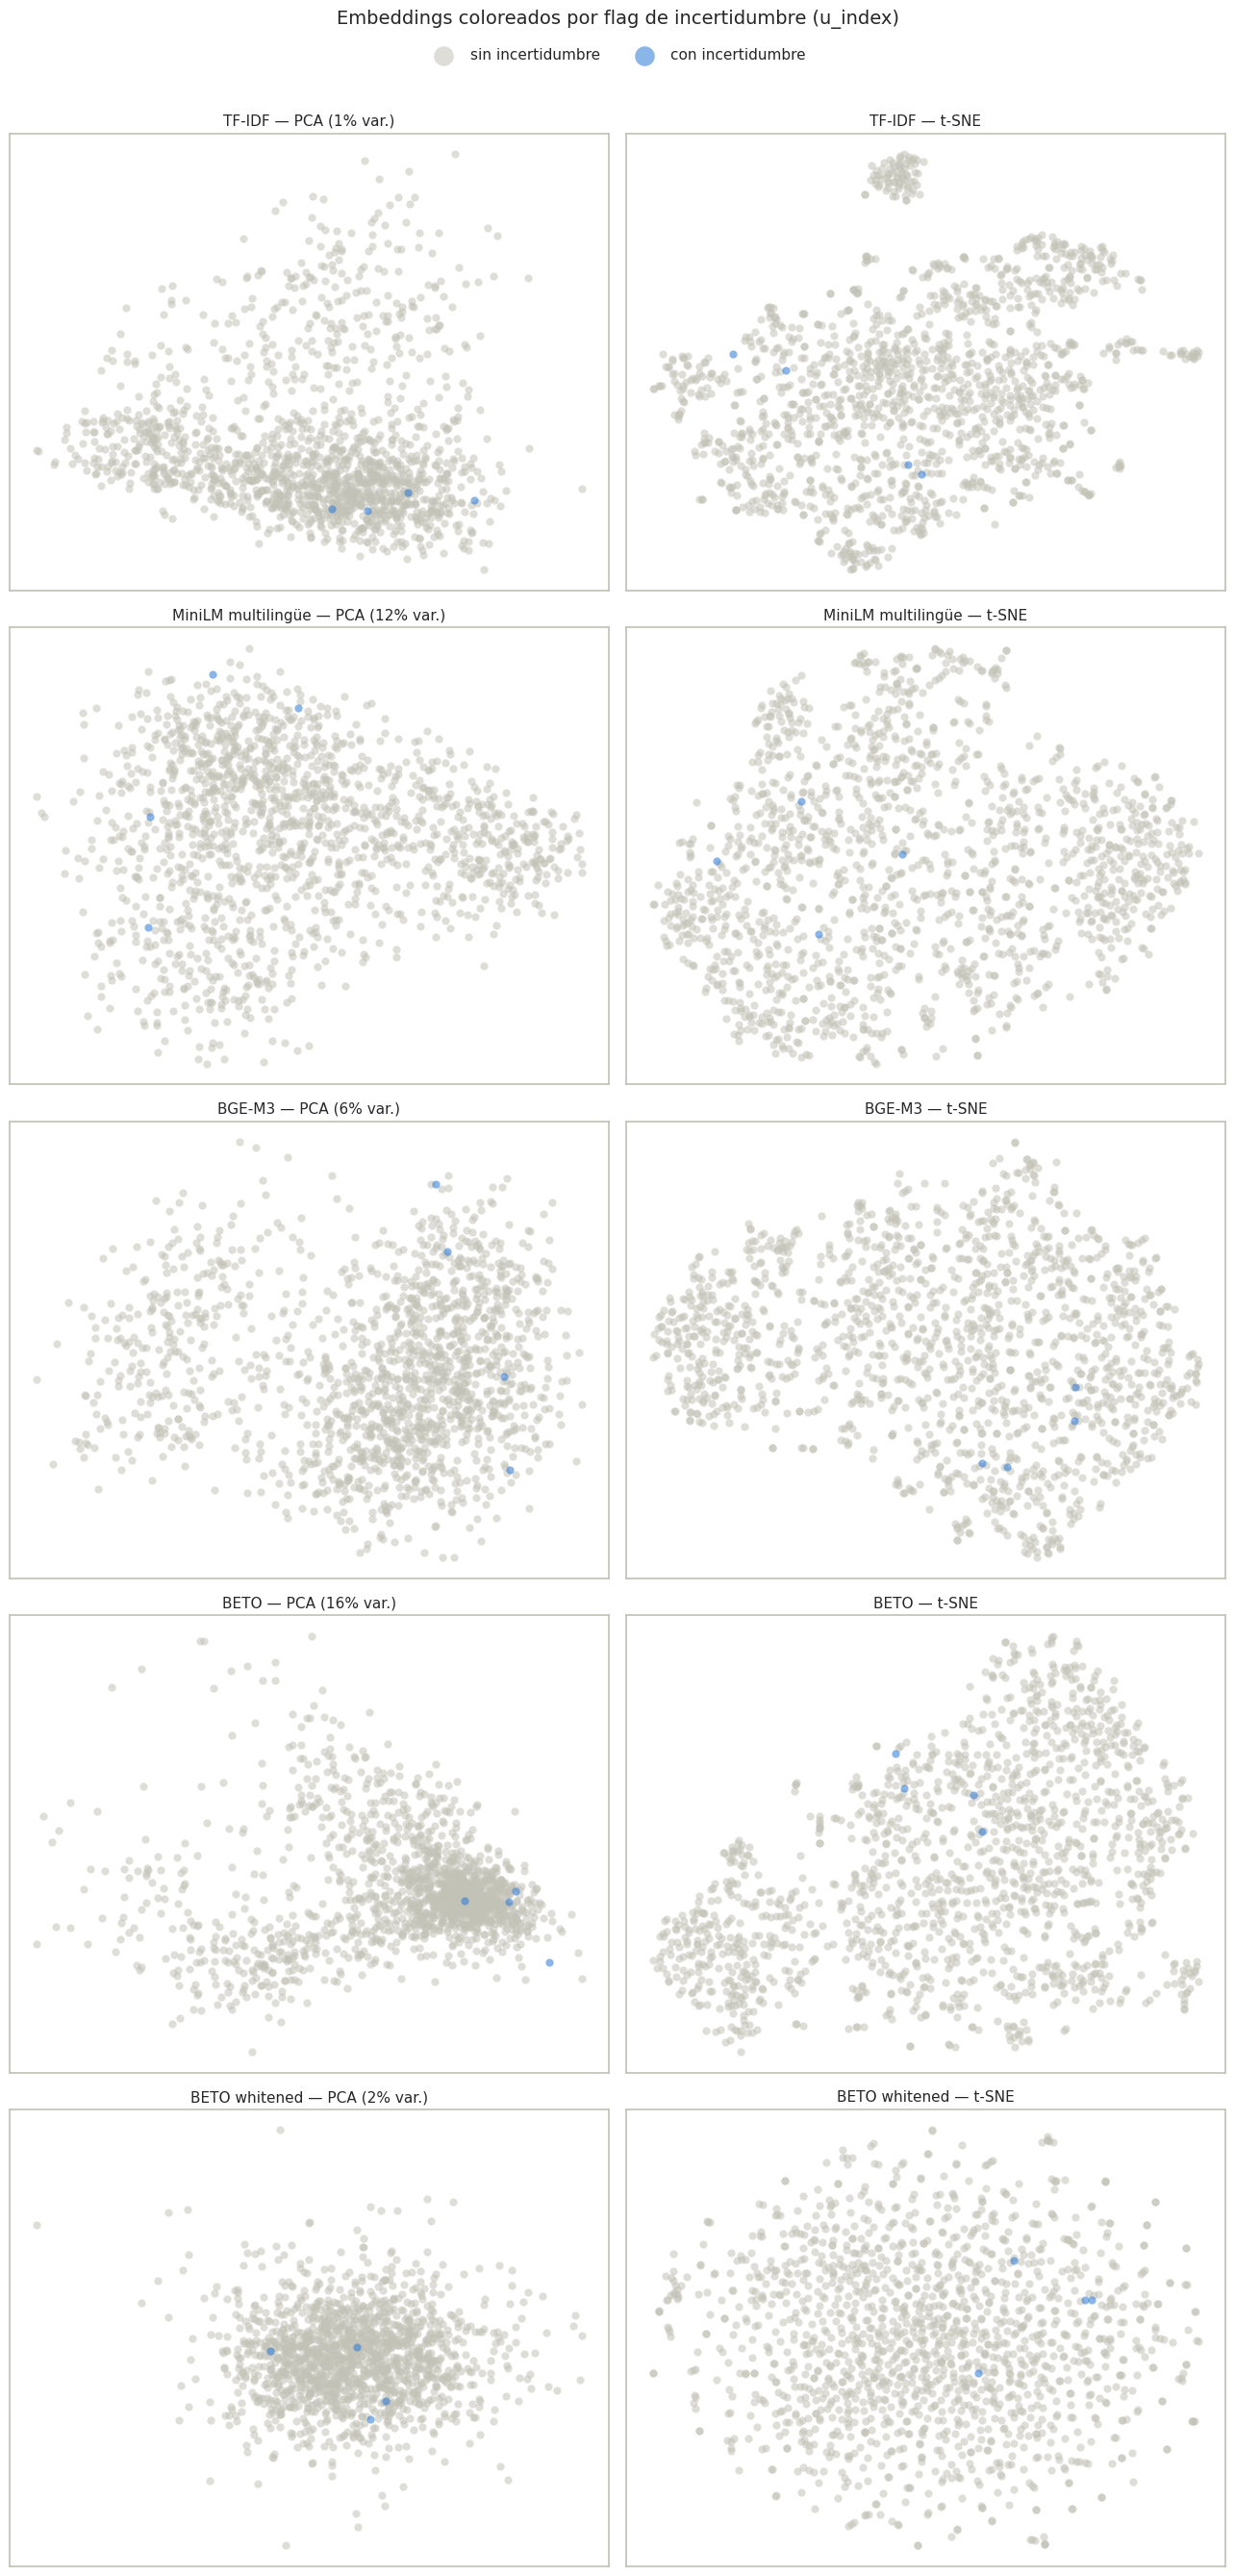

In [24]:
plot_proyecciones("u_index", "Embeddings coloreados por flag de incertidumbre (u_index)",
                  COLOR_FLAG, {0: "sin incertidumbre", 1: "con incertidumbre"})

## Lectura de resultados

- **TF-IDF** separa sobre todo por vocabulario superficial: útil como baseline, pero las
  proyecciones muestran menos estructura semántica compacta.
- **MiniLM multilingüe** produce agrupaciones semánticas visibles pese al truncamiento a
  128 tokens (solo el inicio del artículo).
- **BGE-M3** usa el documento completo dentro del truncado a 2,000 caracteres (contexto 8k)
  y tiene fine-tuning contrastivo, lo que lo hace un candidato fuerte para el pipeline de
  clustering + RAG con Milvus (1024 dims).
- **BETO** es el único que procesa el artículo entero, pero también el único **sin
  fine-tuning contrastivo**. Al comparar su proyección con la de BETO whitened se aísla
  cuánto de lo que se ve es geometría del espacio y cuánto es contenido: si la versión sin
  whitening luce como una nube compacta sin estructura y la whitened muestra grupos, el
  problema era la anisotropía, no la representación.
- Ojo con la varianza explicada por el PCA de BETO: un porcentaje **alto** en 2 componentes
  no es buena señal aquí, sino el síntoma de la dirección común dominante.
- Si los colores por periódico se mezclan dentro de los grupos, la estructura dominante es
  **temática** y no de medio — deseable para clustering de tópicos. La vista por `u_index` es muy dispersa
  porque la flag solo marca ~0.4% de los artículos de la muestra (ver prevalencia arriba);
  con tan pocos positivos no se aprecia concentración regional clara en 2D.

**Comparabilidad:** la elección entre estos métodos no debería cerrarse solo con estas
proyecciones. BETO ve más texto que los demás, así que parte de cualquier ventaja aparente
es cobertura, no calidad — `hc_clustering.ipynb` mide ese sesgo (η² de longitud) y evalúa
las cinco representaciones con métricas de clustering supervisadas y no supervisadas.

**Siguiente paso** (fuera de este notebook): elegir el método definitivo, calcular
embeddings sobre el corpus completo e indexarlos en Milvus.
